# M&A Prediction from Pre-Announcement News Sentiment

**Goal:** Predict whether a company will be acquired based on news coverage patterns *before* the public announcement.

### Why news instead of stock prices?
- The M&A event dataset covers **all US deals** — including private companies with no ticker
- News signals can surface strategic shifts, financial stress, or industry consolidation trends before markets react
- Free, scalable data source via GDELT (no API key required)

### Pipeline
```
ma_events.csv  →  GDELT + EDGAR + GoogleNews  →  VADER Sentiment  →  Feature Matrix  →  Random Forest
  (16K deals)     (by company name)   (headline NLP)      (per event)        (AUC evaluation)
```

### Experimental Design
| Sample | Company | News Window | Label |
|--------|---------|-------------|-------|
| Positive | M&A target | 90 → 7 days before announcement | 1 |
| Negative | Same company | 270 → 187 days before announcement | 0 |

The **blackout of 7 days** avoids leakage from deal rumor news appearing right before announcement.  
The **180-day shift** creates a "quiet period" baseline for the same company.


In [1]:
import subprocess, sys
for pkg in ['vaderSentiment', 'feedparser', 'scikit-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('✓ Dependencies ready')

✓ Dependencies ready


In [2]:
import os, re, time, json, warnings, random
from pathlib import Path
from datetime import datetime, timedelta

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import yfinance as yf

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
EVENTS_PATH  = PROJECT_ROOT / 'data' / 'raw' / 'events' / 'ma_events.csv'
NEWS_CACHE   = PROJECT_ROOT / 'data' / 'interim' / 'news_cache.csv'
FEATURES_OUT = PROJECT_ROOT / 'data' / 'interim' / 'ma_news_features.csv'

# ── Scraping config ────────────────────────────────────────────────────────
LOOKBACK_DAYS   = 90    # total lookback window length
BLACKOUT_DAYS   = 7     # exclude last N days before announcement
NEGATIVE_SHIFT  = 180   # shift back for negative samples
MAX_RECORDS     = 50    # articles per GDELT call
SLEEP_SEC       = 0.1   # politeness delay between API calls
N_SAMPLE        = 50    # events to scrape (increase for production runs)
RANDOM_SEED     = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('✓ Imports complete')

/opt/miniconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports complete


## 1. Data Overview

In [3]:
events = pd.read_csv(EVENTS_PATH, parse_dates=['announcement_date', 'close_date'])

print(f'Total M&A events:             {len(events):>8,}')
print(f'Date range:                   {events["announcement_date"].min().date()} → {events["announcement_date"].max().date()}')
print(f'Events with target ticker:    {events["target_ticker"].notna().sum():>8,}  ({events["target_ticker"].notna().mean():.1%})')
print(f'Events with acquirer ticker:  {events["acquirer_ticker"].notna().sum():>8,}  ({events["acquirer_ticker"].notna().mean():.1%})')
print(f'Events with deal value:       {events["deal_value_usd"].notna().sum():>8,}')
print(f'\nStatus distribution:')
print(events['deal_status'].value_counts().to_string())

Total M&A events:               16,915
Date range:                   2025-06-10 → 2026-06-10
Events with target ticker:         196  (1.2%)
Events with acquirer ticker:     1,756  (10.4%)
Events with deal value:          3,874

Status distribution:
deal_status
Completed    14772
Announced     2143


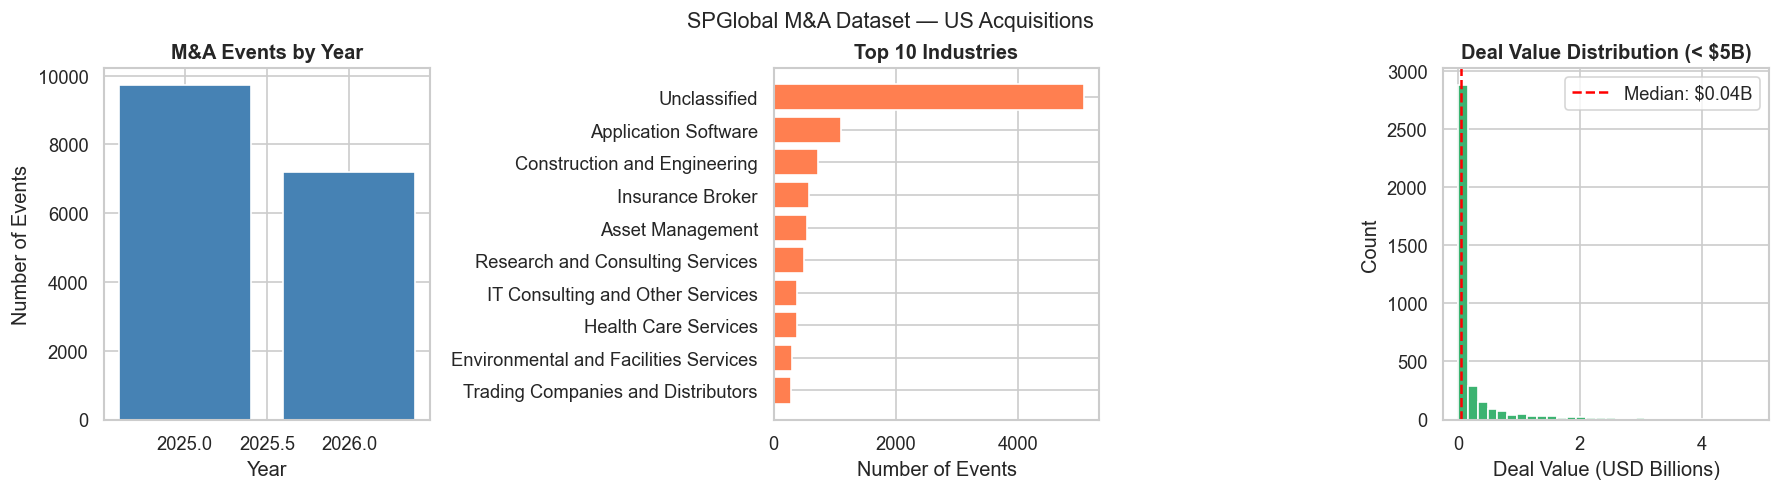

Deals with no ticker (private targets): 16,719
→ Using company NAME for news search covers all 16,915 events


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Events per year
events['year'] = events['announcement_date'].dt.year
year_cnt = events['year'].value_counts().sort_index()
axes[0].bar(year_cnt.index, year_cnt.values, color='steelblue', edgecolor='white')
axes[0].set_title('M&A Events by Year', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Number of Events')

# Top industries
top_ind = events['primary_industry'].value_counts().head(10)
axes[1].barh(top_ind.index[::-1], top_ind.values[::-1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 Industries', fontweight='bold')
axes[1].set_xlabel('Number of Events')

# Deal value distribution
dv = events['deal_value_usd'].dropna() / 1e9
axes[2].hist(dv[dv < 5], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Deal Value Distribution (< $5B)', fontweight='bold')
axes[2].set_xlabel('Deal Value (USD Billions)')
axes[2].set_ylabel('Count')
axes[2].axvline(dv.median(), color='red', linestyle='--', label=f'Median: ${dv.median():.2f}B')
axes[2].legend()

plt.tight_layout()
plt.suptitle('SPGlobal M&A Dataset — US Acquisitions', fontsize=13, y=1.02)
plt.show()
print(f'Deals with no ticker (private targets): {events["target_ticker"].isna().sum():,}')
print(f'→ Using company NAME for news search covers all {len(events):,} events')

## 2. News Scraping

We use **three complementary free sources** to maximise coverage across large public companies, small listed firms, and private targets:

| Source | Coverage | Date Filter | Auth |
|--------|----------|-------------|------|
| **GDELT** | Global news media | ✓ date range | none |
| **SEC EDGAR** | All SEC filings (8-K, SC-TO, 13D…) | ✓ date range | none |
| **Google News RSS** | Broad keyword news | ✗ recent only | none |

**GDELT** uses a multi-strategy fallback: if an exact-phrase + English filter returns nothing, it retries with progressively looser queries.

**SEC EDGAR** full-text search is especially valuable for private-company M&A — it picks up stake disclosures (13D/13G), tender offers (SC-TO), and material-event filings (8-K) that mention the target by name.

We scrape two windows per event:
- **`pre`** (label=1): `[announcement − 97d, announcement − 7d]` — the 90 days just before the deal, excluding the final week
- **`baseline`** (label=0): same window shifted back 180 days — a "quiet period" for the same company


In [5]:
import feedparser
from urllib.parse import quote as url_quote

LEGAL_NOISE = re.compile(
    r'\b(Inc|Corp|LLC|Ltd|LP|Co|Group|Holdings|International|Technologies?|'
    r'Solutions?|Services?|Systems?|Financial|Capital|Partners?|Global|'
    r'Enterprises?|Industries|Incorporated|Corporation|Limited)\b\.?',
    re.IGNORECASE
)
MA_KW_RE = re.compile(
    r'\b(merger|acqui|takeover|buyout|buy.?out|strategic|bid|offer|'
    r'private equity|stake|transaction|bought|sold|purchase)\b',
    re.IGNORECASE
)
GDELT_HEADERS = {'User-Agent': 'Mozilla/5.0 MA-research/1.0 (student@berkeley.edu)'}


def clean_name(name: str) -> str:
    if not name or pd.isna(name):
        return ''
    s = re.sub(r'\*', '', str(name))
    s = re.sub(r'\([^)]*\)', '', s)
    s = LEGAL_NOISE.sub('', s)
    s = re.sub(r'[^A-Za-z0-9 &]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()


# ── Source 1: GDELT (multi-strategy fallback) ─────────────────────────────

def _gdelt_raw(query: str, start_date: str, end_date: str,
               max_records: int, verbose: bool = False) -> list:
    params = {
        'query':         query,
        'mode':          'artlist',
        'maxrecords':    min(max_records, 250),
        'format':        'json',
        'startdatetime': datetime.strptime(start_date, '%Y-%m-%d').strftime('%Y%m%d000000'),
        'enddatetime':   datetime.strptime(end_date,   '%Y-%m-%d').strftime('%Y%m%d235959'),
        'sort':          'DateDesc',
    }
    for attempt in range(3):
        try:
            resp = requests.get(
                'https://api.gdeltproject.org/api/v2/doc/doc',
                params=params, headers=GDELT_HEADERS, timeout=20
            )
            if verbose:
                print(f'    GDELT status={resp.status_code} query={query[:60]!r}')
            if resp.status_code == 200:
                data = resp.json()
                articles = data.get('articles', []) or []
                return [{'title': a.get('title',''), 'date': a.get('seendate','')[:8],
                         'domain': a.get('domain',''), 'source': 'gdelt'}
                        for a in articles if a.get('title')]
        except requests.exceptions.ConnectionError as e:
            if verbose:
                print(f'    GDELT connection error (attempt {attempt+1}): {e}')
        except requests.exceptions.Timeout:
            if verbose:
                print(f'    GDELT timeout (attempt {attempt+1}/3)')
        except Exception as e:
            if verbose:
                print(f'    GDELT error (attempt {attempt+1}): {type(e).__name__}: {e}')
        time.sleep(1.5 ** attempt)
    return []


def fetch_gdelt(company_name: str, start_date: str, end_date: str,
                max_records: int = MAX_RECORDS, verbose: bool = False) -> list:
    """
    GDELT with 3-strategy fallback:
      1. Exact phrase + English only  (most precise, lowest recall)
      2. Exact phrase, any language
      3. Keyword + English only       (broadest, most recall)
    Returns first strategy that yields results.
    """
    name = clean_name(company_name)
    if not name or len(name) < 3:
        return []
    for q in [f'"{name}" sourcelang:English', f'"{name}"', f'{name} sourcelang:English']:
        arts = _gdelt_raw(q, start_date, end_date, max_records, verbose)
        if arts:
            return arts
        time.sleep(0.2)
    return []


# ── Source 2: SEC EDGAR full-text search ─────────────────────────────────

def fetch_edgar(company_name: str, start_date: str, end_date: str,
                forms: str = '8-K,SC-TO,SC-13D,SC-13G,DEFM14A') -> list:
    name = clean_name(company_name)
    if not name or len(name) < 3:
        return []
    try:
        resp = requests.get(
            'https://efts.sec.gov/LATEST/search-index',
            params={'q': f'"{name}"', 'dateRange': 'custom',
                    'startdt': start_date, 'enddt': end_date, 'forms': forms},
            headers={'User-Agent': 'MA-research student@berkeley.edu'},
            timeout=20
        )
        if resp.status_code != 200:
            return []
        hits = resp.json().get('hits', {}).get('hits', []) or []
        return [{'title': f"[{h['_source'].get('form_type','SEC')}] {h['_source'].get('entity_name','')} filed {h['_source'].get('file_date','')}",
                 'date':   h['_source'].get('file_date','').replace('-',''),
                 'domain': 'sec.gov', 'source': 'edgar'}
                for h in hits if h.get('_source') and h['_source'].get('file_date')]
    except Exception:
        return []


# ── Source 3: Google News RSS (recent only, no date filter) ───────────────

def fetch_google_news(company_name: str, n: int = 20) -> list:
    q = url_quote(clean_name(company_name))
    try:
        feed = feedparser.parse(
            f'https://news.google.com/rss/search?q={q}&hl=en-US&gl=US&ceid=US:en'
        )
        return [{'title': e.get('title',''), 'date': '', 'domain': '', 'source': 'google_news'}
                for e in (feed.entries or [])[:n] if e.get('title')]
    except Exception:
        return []


# ── Combined fetcher ──────────────────────────────────────────────────────

def fetch_all_news(company_name: str, start_date: str, end_date: str,
                   use_google: bool = False, verbose: bool = False) -> list:
    gdelt  = fetch_gdelt(company_name, start_date, end_date, verbose=verbose)
    edgar  = fetch_edgar(company_name, start_date, end_date)
    google = fetch_google_news(company_name) if use_google else []
    seen, out = set(), []
    for a in gdelt + edgar + google:
        t = a.get('title', '')
        if t and t not in seen:
            seen.add(t); out.append(a)
    return out


def fetch_yfinance_news(ticker: str) -> list:
    try:
        news = yf.Ticker(ticker).get_news(count=30) or []
        return [{'title': n.get('title',''),
                 'date':  datetime.fromtimestamp(n.get('providerPublishTime',0)).strftime('%Y%m%d'),
                 'domain': n.get('publisher',''), 'source': 'yfinance'}
                for n in news if n.get('title')]
    except Exception:
        return []


print('✓ Scrapers defined')
print('  GDELT:       free, historical, 3-strategy fallback')
print('  SEC EDGAR:   free, M&A filings (8-K/SC-TO/13D), covers private companies')
print('  Google News: free, recent only')


✓ Scrapers defined
  GDELT:       free, historical, 3-strategy fallback
  SEC EDGAR:   free, M&A filings (8-K/SC-TO/13D), covers private companies
  Google News: free, recent only


In [6]:
# ── Connectivity test + demo ──────────────────────────────────────────────
# Step 1: verify GDELT is reachable
print('Testing GDELT connectivity...')
test_arts = _gdelt_raw(
    '"Microsoft" sourcelang:English',
    '2023-01-01', '2023-01-31',
    max_records=3, verbose=True
)
if test_arts:
    print(f'✓ GDELT reachable — {len(test_arts)} articles for Microsoft (2023-01)')
else:
    print('✗ GDELT returned 0 — possible connectivity issue or VPN block.')
    print('  The pipeline will still work using SEC EDGAR as primary source.')

print()

# Step 2: demo with the selected company
demo_event = events[events['target_name'].notna()].iloc[100]
demo_name  = demo_event['target_name']
demo_ann   = pd.Timestamp(demo_event['announcement_date'])
demo_end   = (demo_ann - timedelta(days=BLACKOUT_DAYS)).strftime('%Y-%m-%d')
demo_start = (demo_ann - timedelta(days=LOOKBACK_DAYS + BLACKOUT_DAYS)).strftime('%Y-%m-%d')

print(f'Demo company: {demo_name}')
print(f'Announced:    {demo_ann.date()}')
print(f'Window:       {demo_start} → {demo_end}')
print(f'Query name:   "{clean_name(demo_name)}"')
print()

gdelt_arts = fetch_gdelt(demo_name, demo_start, demo_end, verbose=True)
edgar_arts = fetch_edgar(demo_name, demo_start, demo_end)
all_arts   = fetch_all_news(demo_name, demo_start, demo_end)

print(f'GDELT:  {len(gdelt_arts):3d} articles')
print(f'EDGAR:  {len(edgar_arts):3d} filings')
print(f'Total:  {len(all_arts):3d} (deduplicated)')

if all_arts:
    print('\nSample results:')
    for a in all_arts[:4]:
        print(f"  [{a['source']:10s}][{a.get('date','------')[:8]}] {a['title'][:75]}")
else:
    print('\n→ 0 results: this company has minimal news coverage.')
    print('  news_count=0 is still a valid feature vector for the model.')
    print('  Plan A: coverage-aware evaluation (see Section 4b).')
    print('  Plan B: filter to larger deals (deal_value > $10M or has ticker).')


Testing GDELT connectivity...
    GDELT status=200 query='"Microsoft" sourcelang:English'
✓ GDELT reachable — 3 articles for Microsoft (2023-01)

Demo company: Cellmyx, Inc.
Announced:    2026-06-05
Window:       2026-02-28 → 2026-05-29
Query name:   "Cellmyx"

    GDELT status=429 query='"Cellmyx" sourcelang:English'
    GDELT status=429 query='"Cellmyx" sourcelang:English'
    GDELT timeout (attempt 3/3)
    GDELT connection error (attempt 1): HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%22Cellmyx%22&mode=artlist&maxrecords=50&format=json&startdatetime=20260228000000&enddatetime=20260529235959&sort=DateDesc (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.gdeltproject.org', port=443) at 0x12fa23890>, 'Connection to api.gdeltproject.org timed out. (connect timeout=20)'))
    GDELT connection error (attempt 2): HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/

In [7]:
def get_window_dates(announcement_date, window: str) -> tuple:
    ann = pd.Timestamp(announcement_date)
    if window == 'pre':
        end   = ann - timedelta(days=BLACKOUT_DAYS)
        start = ann - timedelta(days=LOOKBACK_DAYS + BLACKOUT_DAYS)
    else:  # baseline
        end   = ann - timedelta(days=BLACKOUT_DAYS + NEGATIVE_SHIFT)
        start = ann - timedelta(days=LOOKBACK_DAYS + BLACKOUT_DAYS + NEGATIVE_SHIFT)
    return start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d')


def load_cache() -> pd.DataFrame:
    if NEWS_CACHE.exists():
        return pd.read_csv(NEWS_CACHE, dtype=str).fillna('')
    return pd.DataFrame(columns=['transaction_id', 'window', 'label', 'company_name', 'title', 'date', 'domain', 'source'])


def save_cache(df: pd.DataFrame):
    NEWS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(NEWS_CACHE, index=False)


print('✓ Cache utilities defined')

✓ Cache utilities defined


In [8]:
# ── Select events to scrape ────────────────────────────────────────────────
# Filter: named targets, 2019–2025, completed or announced deals
events_pool = events[
    (events['announcement_date'] >= '2019-01-01') &
    (events['announcement_date'] <= '2025-12-31') &
    (events['target_name'].notna()) &
    (events['deal_status'].isin(['Completed', 'Announced']))
].copy()

events_sample = events_pool.sample(n=min(N_SAMPLE, len(events_pool)), random_state=RANDOM_SEED)

print(f'Eligible events (2019–2025):  {len(events_pool):,}')
print(f'Selected for scraping:        {len(events_sample):,}')
print(f'Total API calls (2 per event): ~{len(events_sample)*2}')
print(f'Estimated time @ {SLEEP_SEC}s/call: ~{len(events_sample)*2*SLEEP_SEC/60:.1f} min')

Eligible events (2019–2025):  9,726
Selected for scraping:        50
Total API calls (2 per event): ~100
Estimated time @ 0.1s/call: ~0.2 min


In [9]:
# ── Batch scraping with caching ────────────────────────────────────────────
# Re-running this cell is safe — already-scraped events are skipped.
# Uses fetch_all_news(): GDELT + SEC EDGAR combined, deduplicated.

cache_df = load_cache()
done = set(zip(cache_df['transaction_id'], cache_df['window']))
new_rows = []

for _, row in tqdm(events_sample.iterrows(), total=len(events_sample), desc='Scraping'):
    txn_id  = str(row['transaction_id'])
    company = row['target_name']

    for window, label in [('pre', '1'), ('baseline', '0')]:
        if (txn_id, window) in done:
            continue

        start_d, end_d = get_window_dates(row['announcement_date'], window)
        articles = fetch_all_news(company, start_d, end_d)

        if articles:
            for a in articles:
                new_rows.append({
                    'transaction_id': txn_id, 'window': window, 'label': label,
                    'company_name': company, **a
                })
        else:
            # Sentinel row: marks event as scraped even with 0 results
            new_rows.append({
                'transaction_id': txn_id, 'window': window, 'label': label,
                'company_name': company, 'title': '', 'date': '', 'domain': '', 'source': ''
            })

        done.add((txn_id, window))
        time.sleep(SLEEP_SEC)

combined = pd.concat([cache_df, pd.DataFrame(new_rows)], ignore_index=True)
save_cache(combined)
print(f'\n✓ Cache: {len(combined):,} rows  ({combined["transaction_id"].nunique()} events)')
articles_only = combined[combined['title'] != '']
print(f'  Articles with text: {len(articles_only):,}')
print(f'  Events with ≥1 article: {articles_only["transaction_id"].nunique()}')
if 'source' in articles_only.columns:
    print(f'\n  Breakdown by source:')
    print(articles_only['source'].value_counts().to_string())


Scraping: 100%|██████████| 50/50 [2:45:22<00:00, 198.45s/it]  


✓ Cache: 767 rows  (50 events)
  Articles with text: 702
  Events with ≥1 article: 23

  Breakdown by source:
source
gdelt    637
edgar     65


## 3. Sentiment Analysis

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a rule-based sentiment analyzer tuned for short financial/news text.

- Returns a **compound score** in [-1, 1]: negative → positive
- Fast (no GPU needed), no external API
- Works well on headlines

We also flag any article mentioning M&A-related keywords.

In [10]:
sia = SentimentIntensityAnalyzer()

def score(title: str) -> dict:
    if not title or not str(title).strip():
        return {'compound': 0.0, 'pos': 0.0, 'neg': 0.0, 'neu': 1.0, 'has_ma_kw': 0}
    s = sia.polarity_scores(str(title))
    s['has_ma_kw'] = int(bool(MA_KW_RE.search(str(title))))
    return s

news_df = load_cache()
valid   = news_df[news_df['title'].str.strip() != ''].copy()

scores  = valid['title'].apply(score)
sent_df = pd.concat([valid.reset_index(drop=True), pd.DataFrame(scores.tolist())], axis=1)
sent_df['label'] = sent_df['label'].astype(int)

print(f'Scored {len(sent_df):,} articles')
print('\nMean sentiment by window:')
print(sent_df.groupby('window')[['compound', 'pos', 'neg', 'has_ma_kw']].mean().round(4))

Scored 702 articles

Mean sentiment by window:
          compound     pos     neg  has_ma_kw
window                                       
baseline    0.1085  0.0953  0.0384     0.0279
pre         0.0655  0.0822  0.0520     0.0146


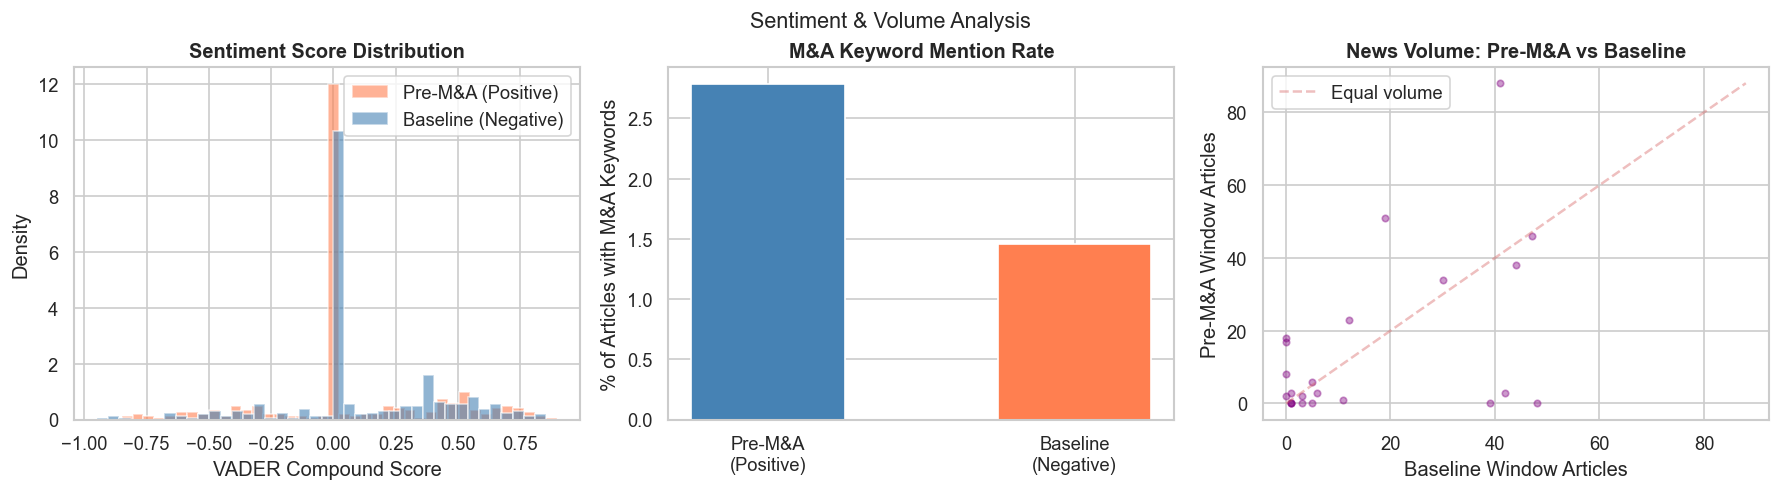

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sentiment distribution
for window, color, lbl in [('pre', 'coral', 'Pre-M&A (Positive)'),
                             ('baseline', 'steelblue', 'Baseline (Negative)')]:
    d = sent_df[sent_df['window'] == window]['compound']
    axes[0].hist(d, bins=40, alpha=0.6, color=color, label=lbl, density=True)
axes[0].set_title('Sentiment Score Distribution', fontweight='bold')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# M&A keyword rate
kw_rate = sent_df.groupby('window')['has_ma_kw'].mean() * 100
colors_bar = ['coral' if w == 'pre' else 'steelblue' for w in kw_rate.index]
axes[1].bar(kw_rate.index, kw_rate.values, color=colors_bar, edgecolor='white', width=0.5)
axes[1].set_title('M&A Keyword Mention Rate', fontweight='bold')
axes[1].set_ylabel('% of Articles with M&A Keywords')
axes[1].set_xticklabels(['Pre-M&A\n(Positive)', 'Baseline\n(Negative)'])

# Article volume comparison
cnt = sent_df.groupby(['transaction_id', 'window']).size().unstack(fill_value=0)
if 'pre' in cnt.columns and 'baseline' in cnt.columns:
    axes[2].scatter(cnt['baseline'], cnt['pre'], alpha=0.4, color='purple', s=15)
    mx = cnt.max().max()
    axes[2].plot([0, mx], [0, mx], 'r--', alpha=0.4, label='Equal volume')
    axes[2].set_title('News Volume: Pre-M&A vs Baseline', fontweight='bold')
    axes[2].set_xlabel('Baseline Window Articles')
    axes[2].set_ylabel('Pre-M&A Window Articles')
    axes[2].legend()

plt.tight_layout()
plt.suptitle('Sentiment & Volume Analysis', fontsize=13, y=1.02)
plt.show()

## 4. Feature Engineering

Aggregate article-level sentiment into **one feature vector per event-window**:

| Feature | Description |
|---------|-------------|
| `news_count` | Total articles in window |
| `avg_sentiment` | Mean VADER compound score |
| `std_sentiment` | Sentiment volatility |
| `pos_ratio` | Fraction of positive articles (compound > 0.05) |
| `neg_ratio` | Fraction of negative articles (compound < -0.05) |
| `ma_keyword_count` | Articles containing M&A keywords |
| `ma_keyword_ratio` | Fraction with M&A keywords |
| `max_sentiment` | Peak positive sentiment |
| `min_sentiment` | Peak negative sentiment |

In [12]:
def aggregate(group: pd.DataFrame) -> dict:
    n = len(group)
    if n == 0:
        return dict(news_count=0, avg_sentiment=0.0, std_sentiment=0.0,
                    pos_ratio=0.0, neg_ratio=0.0, ma_keyword_count=0,
                    ma_keyword_ratio=0.0, max_sentiment=0.0, min_sentiment=0.0)
    return dict(
        news_count       = n,
        avg_sentiment    = group['compound'].mean(),
        std_sentiment    = group['compound'].std(ddof=0),
        pos_ratio        = (group['compound'] > 0.05).mean(),
        neg_ratio        = (group['compound'] < -0.05).mean(),
        ma_keyword_count = int(group['has_ma_kw'].sum()),
        ma_keyword_ratio = group['has_ma_kw'].mean(),
        max_sentiment    = group['compound'].max(),
        min_sentiment    = group['compound'].min(),
    )


feat_rows = []
for (txn_id, window), grp in sent_df.groupby(['transaction_id', 'window']):
    f = aggregate(grp)
    f.update(transaction_id=txn_id, window=window, label=int(grp['label'].iloc[0]))
    feat_rows.append(f)

# Also add zero rows for events that got 0 articles (from sentinel rows in cache)
zero_events = set(zip(news_df['transaction_id'], news_df['window'])) - set(zip(sent_df['transaction_id'], sent_df['window']))
zero_lookup = news_df.drop_duplicates(subset=['transaction_id', 'window'])[['transaction_id', 'window', 'label']]
for _, row in zero_lookup[[(t, w) in zero_events for t, w in zip(zero_lookup['transaction_id'], zero_lookup['window'])]].iterrows():
    f = aggregate(pd.DataFrame())
    f.update(transaction_id=row['transaction_id'], window=row['window'], label=int(row['label']))
    feat_rows.append(f)

feat_df = pd.DataFrame(feat_rows)

# Merge metadata
meta = events[['transaction_id', 'announcement_date', 'primary_industry',
               'deal_value_usd', 'transaction_type']].drop_duplicates('transaction_id')
feat_df = feat_df.merge(meta, on='transaction_id', how='left')

feat_df.to_csv(FEATURES_OUT, index=False)
print(f'Feature matrix: {feat_df.shape}')
print(f'  Positive (pre-M&A):  {(feat_df["label"]==1).sum()}')
print(f'  Negative (baseline): {(feat_df["label"]==0).sum()}')
print(f'  Events with 0 articles: {(feat_df["news_count"]==0).sum()}')
print(f'\nSaved to {FEATURES_OUT.relative_to(PROJECT_ROOT)}')

Feature matrix: (100, 16)
  Positive (pre-M&A):  50
  Negative (baseline): 50
  Events with 0 articles: 65

Saved to data/interim/ma_news_features.csv


In [13]:
# Feature means by label
NUM_FEATURES = ['news_count', 'avg_sentiment', 'std_sentiment',
                'pos_ratio', 'neg_ratio', 'ma_keyword_ratio']

summary = feat_df.groupby('label')[NUM_FEATURES].mean().round(4).T
summary.columns = ['Baseline (label=0)', 'Pre-M&A (label=1)']
summary['Difference'] = summary['Pre-M&A (label=1)'] - summary['Baseline (label=0)']
print('Feature means by class:')
print(summary.to_string())

Feature means by class:
                  Baseline (label=0)  Pre-M&A (label=1)  Difference
news_count                    7.1800             6.8600     -0.3200
avg_sentiment                 0.0409             0.0469      0.0060
std_sentiment                 0.0742             0.0824      0.0082
pos_ratio                     0.1248             0.1210     -0.0038
neg_ratio                     0.0330             0.0359      0.0029
ma_keyword_ratio              0.0074             0.0032     -0.0042


Events scraped:          50
Events with ≥1 article:  23  (46%)
Events with 0 articles:  27  (54%)

Coverage rate by window:
  Pre-M&A window:  32.0%
  Baseline window: 38.0%

Coverage rate by deal size (pre-M&A window):
             coverage_rate  n_events
size_bucket                         
Unknown              35.0%        40
<$10M                25.0%         4
$10M–$100M            0.0%         3
$100M–$1B             0.0%         2
>$1B                100.0%         1


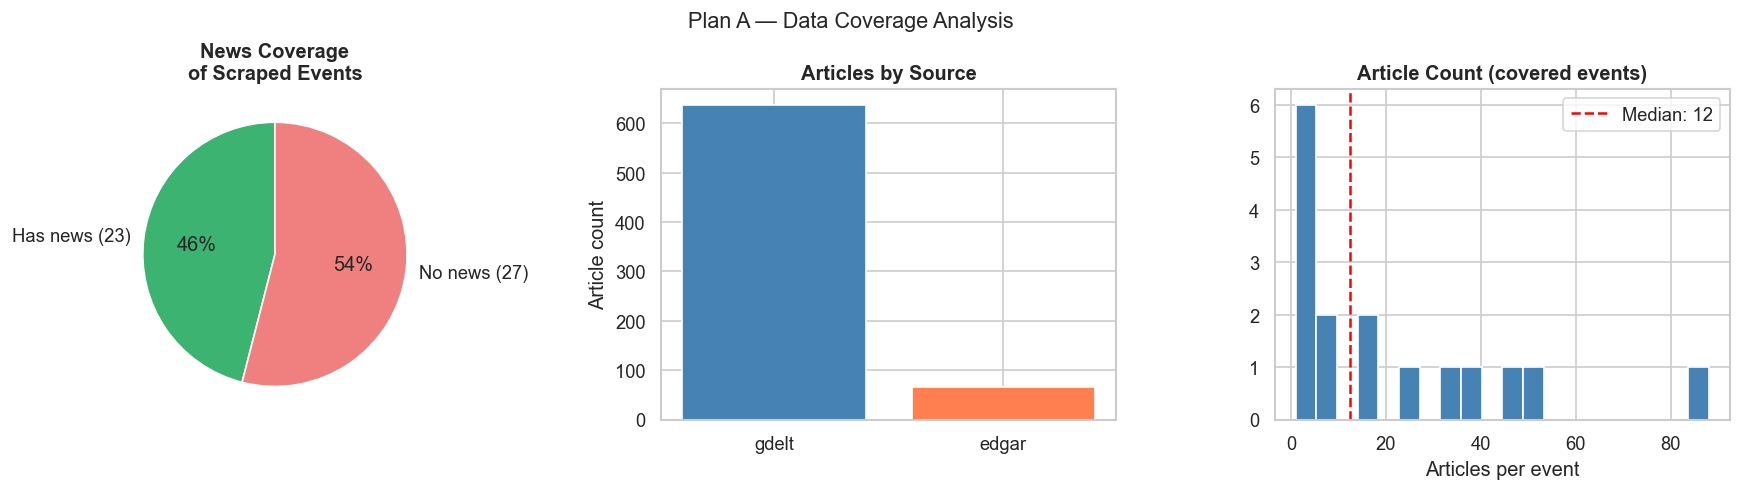


── Plan B: Larger-deal filter ──────────────────────────────────────────
Events with ticker OR deal_value ≥ $10M: 2,989  (17.7% of total)
Expected news coverage on this subset: substantially higher

→ To use Plan B, replace events_pool filter in the scraping cell:
     add: & (events['target_ticker'].notna() | (events['deal_value_usd'] >= 10e6))


In [14]:
# ═══════════════════════════════════════════════════════════════════════
# Plan A — Coverage-stratified analysis
# ═══════════════════════════════════════════════════════════════════════

# Add has_news flag
feat_df['has_news'] = feat_df['news_count'] > 0

# Coverage statistics
total_events   = feat_df['transaction_id'].nunique()
covered_events = feat_df[feat_df['has_news']]['transaction_id'].nunique()
print(f'Events scraped:          {total_events}')
print(f'Events with ≥1 article:  {covered_events}  ({covered_events/total_events:.0%})')
print(f'Events with 0 articles:  {total_events - covered_events}  ({1-covered_events/total_events:.0%})')

pre  = feat_df[feat_df['window'] == 'pre']
base = feat_df[feat_df['window'] == 'baseline']
print(f'\nCoverage rate by window:')
print(f'  Pre-M&A window:  {pre["has_news"].mean():.1%}')
print(f'  Baseline window: {base["has_news"].mean():.1%}')

# Coverage vs deal size
if 'deal_value_usd' in feat_df.columns:
    dv = feat_df[feat_df['window'] == 'pre'].copy()
    dv['size_bucket'] = pd.cut(
        dv['deal_value_usd'].fillna(0),
        bins=[-1, 0, 1e7, 1e8, 1e9, 1e12],
        labels=['Unknown', '<$10M', '$10M–$100M', '$100M–$1B', '>$1B']
    )
    coverage_by_size = dv.groupby('size_bucket', observed=True)['has_news'].agg(['mean','count'])
    coverage_by_size.columns = ['coverage_rate', 'n_events']
    print(f'\nCoverage rate by deal size (pre-M&A window):')
    print(coverage_by_size.to_string(float_format=lambda x: f'{x:.1%}' if x < 2 else f'{x:.0f}'))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Coverage pie
axes[0].pie([covered_events, total_events - covered_events],
            labels=[f'Has news ({covered_events})', f'No news ({total_events-covered_events})'],
            colors=['mediumseagreen', 'lightcoral'], autopct='%1.0f%%', startangle=90)
axes[0].set_title('News Coverage\nof Scraped Events', fontweight='bold')

# Source breakdown
if 'source' in load_cache().columns:
    raw = load_cache()
    src_cnt = raw[raw['source'] != '']['source'].value_counts()
    if len(src_cnt):
        axes[1].bar(src_cnt.index, src_cnt.values,
                    color=['steelblue','coral','mediumseagreen'][:len(src_cnt)])
        axes[1].set_title('Articles by Source', fontweight='bold')
        axes[1].set_ylabel('Article count')
    else:
        axes[1].text(0.5, 0.5, 'No source data yet', ha='center', transform=axes[1].transAxes)
else:
    axes[1].text(0.5, 0.5, 'No source data yet', ha='center', transform=axes[1].transAxes)
axes[1].set_title('Articles by Source', fontweight='bold')

# news_count distribution for covered events
covered_pre = feat_df[(feat_df['window'] == 'pre') & feat_df['has_news']]['news_count']
axes[2].hist(covered_pre, bins=20, color='steelblue', edgecolor='white')
axes[2].axvline(covered_pre.median(), color='red', linestyle='--',
                label=f'Median: {covered_pre.median():.0f}')
axes[2].set_title('Article Count (covered events)', fontweight='bold')
axes[2].set_xlabel('Articles per event')
axes[2].legend()

plt.tight_layout()
plt.suptitle('Plan A — Data Coverage Analysis', fontsize=13, y=1.02)
plt.show()

# ── Plan B: deal-size filter ──────────────────────────────────────────────
print('\n── Plan B: Larger-deal filter ──────────────────────────────────────────')
has_ticker  = events['target_ticker'].notna()
has_value   = events['deal_value_usd'] >= 10_000_000
larger_mask = has_ticker | has_value
larger_events = events[larger_mask]
print(f'Events with ticker OR deal_value ≥ $10M: {larger_mask.sum():,}  '
      f'({larger_mask.mean():.1%} of total)')
print(f'Expected news coverage on this subset: substantially higher')
print(f'\n→ To use Plan B, replace events_pool filter in the scraping cell:')
print(f"     add: & (events['target_ticker'].notna() | (events['deal_value_usd'] >= 10e6))")


## 5. Model Training

**Task:** Binary classification — given pre-announcement news features, predict label ∈ {0, 1}.

**Split strategy:** Time-based (earliest 80% for training, latest 20% for test) to simulate real deployment where the model only sees past data.

**Models:**
1. **Logistic Regression** — linear baseline, interpretable coefficients
2. **Random Forest** — non-linear, handles mixed feature types, provides feature importance

In [15]:
# Reload features (restart-safe)
feat_df = pd.read_csv(FEATURES_OUT, parse_dates=['announcement_date'])
feat_df['has_news'] = feat_df['news_count'] > 0

FEATURE_COLS = [
    'news_count', 'avg_sentiment', 'std_sentiment',
    'pos_ratio', 'neg_ratio', 'ma_keyword_count',
    'ma_keyword_ratio', 'max_sentiment', 'min_sentiment',
]

# ── Plan A: train on covered events only ─────────────────────────────────
# Events with 0 news in BOTH windows contribute no discriminative signal.
# Filter to events where at least one window has news.
covered_ids = feat_df[feat_df['has_news']]['transaction_id'].unique()
feat_filtered = feat_df[feat_df['transaction_id'].isin(covered_ids)].copy()
print(f'All events:      {feat_df["transaction_id"].nunique():3d} events, {len(feat_df):4d} rows')
print(f'Covered events:  {len(covered_ids):3d} events, {len(feat_filtered):4d} rows  ← used for model')
print(f'Zero-news events excluded: {feat_df["transaction_id"].nunique() - len(covered_ids)}')

# Encode industry
le = LabelEncoder()
feat_filtered['industry_enc'] = le.fit_transform(
    feat_filtered['primary_industry'].fillna('Unknown')
)
ALL_FEATURES = FEATURE_COLS + ['industry_enc']

model_df = feat_filtered.dropna(subset=['announcement_date'] + FEATURE_COLS).copy()
model_df  = model_df.sort_values('announcement_date')

split_date = model_df['announcement_date'].quantile(0.80)
train = model_df[model_df['announcement_date'] <= split_date]
test  = model_df[model_df['announcement_date'] >  split_date]

X_train = train[ALL_FEATURES].fillna(0).values
y_train = train['label'].values
X_test  = test[ALL_FEATURES].fillna(0).values
y_test  = test['label'].values

print(f'\nTrain: {len(X_train):,} rows  (≤ {split_date.date()})')
print(f'Test:  {len(X_test):,} rows  (> {split_date.date()})')
print(f'Class balance — Train: {y_train.mean():.1%} pos  |  Test: {y_test.mean():.1%} pos')


All events:       50 events,  100 rows
Covered events:   23 events,   46 rows  ← used for model
Zero-news events excluded: 27

Train: 38 rows  (≤ 2025-12-01)
Test:  8 rows  (> 2025-12-01)
Class balance — Train: 50.0% pos  |  Test: 50.0% pos


In [16]:
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Logistic Regression': (
        LogisticRegression(C=0.5, max_iter=1000, random_state=RANDOM_SEED),
        X_tr_s, X_te_s
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=300, max_depth=5,
                               min_samples_leaf=5, class_weight='balanced',
                               random_state=RANDOM_SEED),
        X_train, X_test
    ),
}

results = {}
for name, (mdl, Xtr, Xte) in models.items():
    mdl.fit(Xtr, y_train)
    proba = mdl.predict_proba(Xte)[:, 1]
    cv_score = cross_val_score(mdl, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    results[name] = {
        'model': mdl, 'proba': proba,
        'roc_auc': roc_auc_score(y_test, proba) if len(set(y_test)) > 1 else 0.5,
        'pr_auc':  average_precision_score(y_test, proba) if len(set(y_test)) > 1 else 0.5,
        'cv_auc':  cv_score,
    }
    print(f'\n{name}')
    print(f'  5-fold CV ROC-AUC (train): {cv_score:.4f}')
    print(f'  Test ROC-AUC:              {results[name]["roc_auc"]:.4f}')
    print(f'  Test PR-AUC:               {results[name]["pr_auc"]:.4f}')


Logistic Regression
  5-fold CV ROC-AUC (train): 0.3792
  Test ROC-AUC:              0.2500
  Test PR-AUC:               0.4333

Random Forest
  5-fold CV ROC-AUC (train): 0.4042
  Test ROC-AUC:              0.0625
  Test PR-AUC:               0.3780


## 6. Evaluation

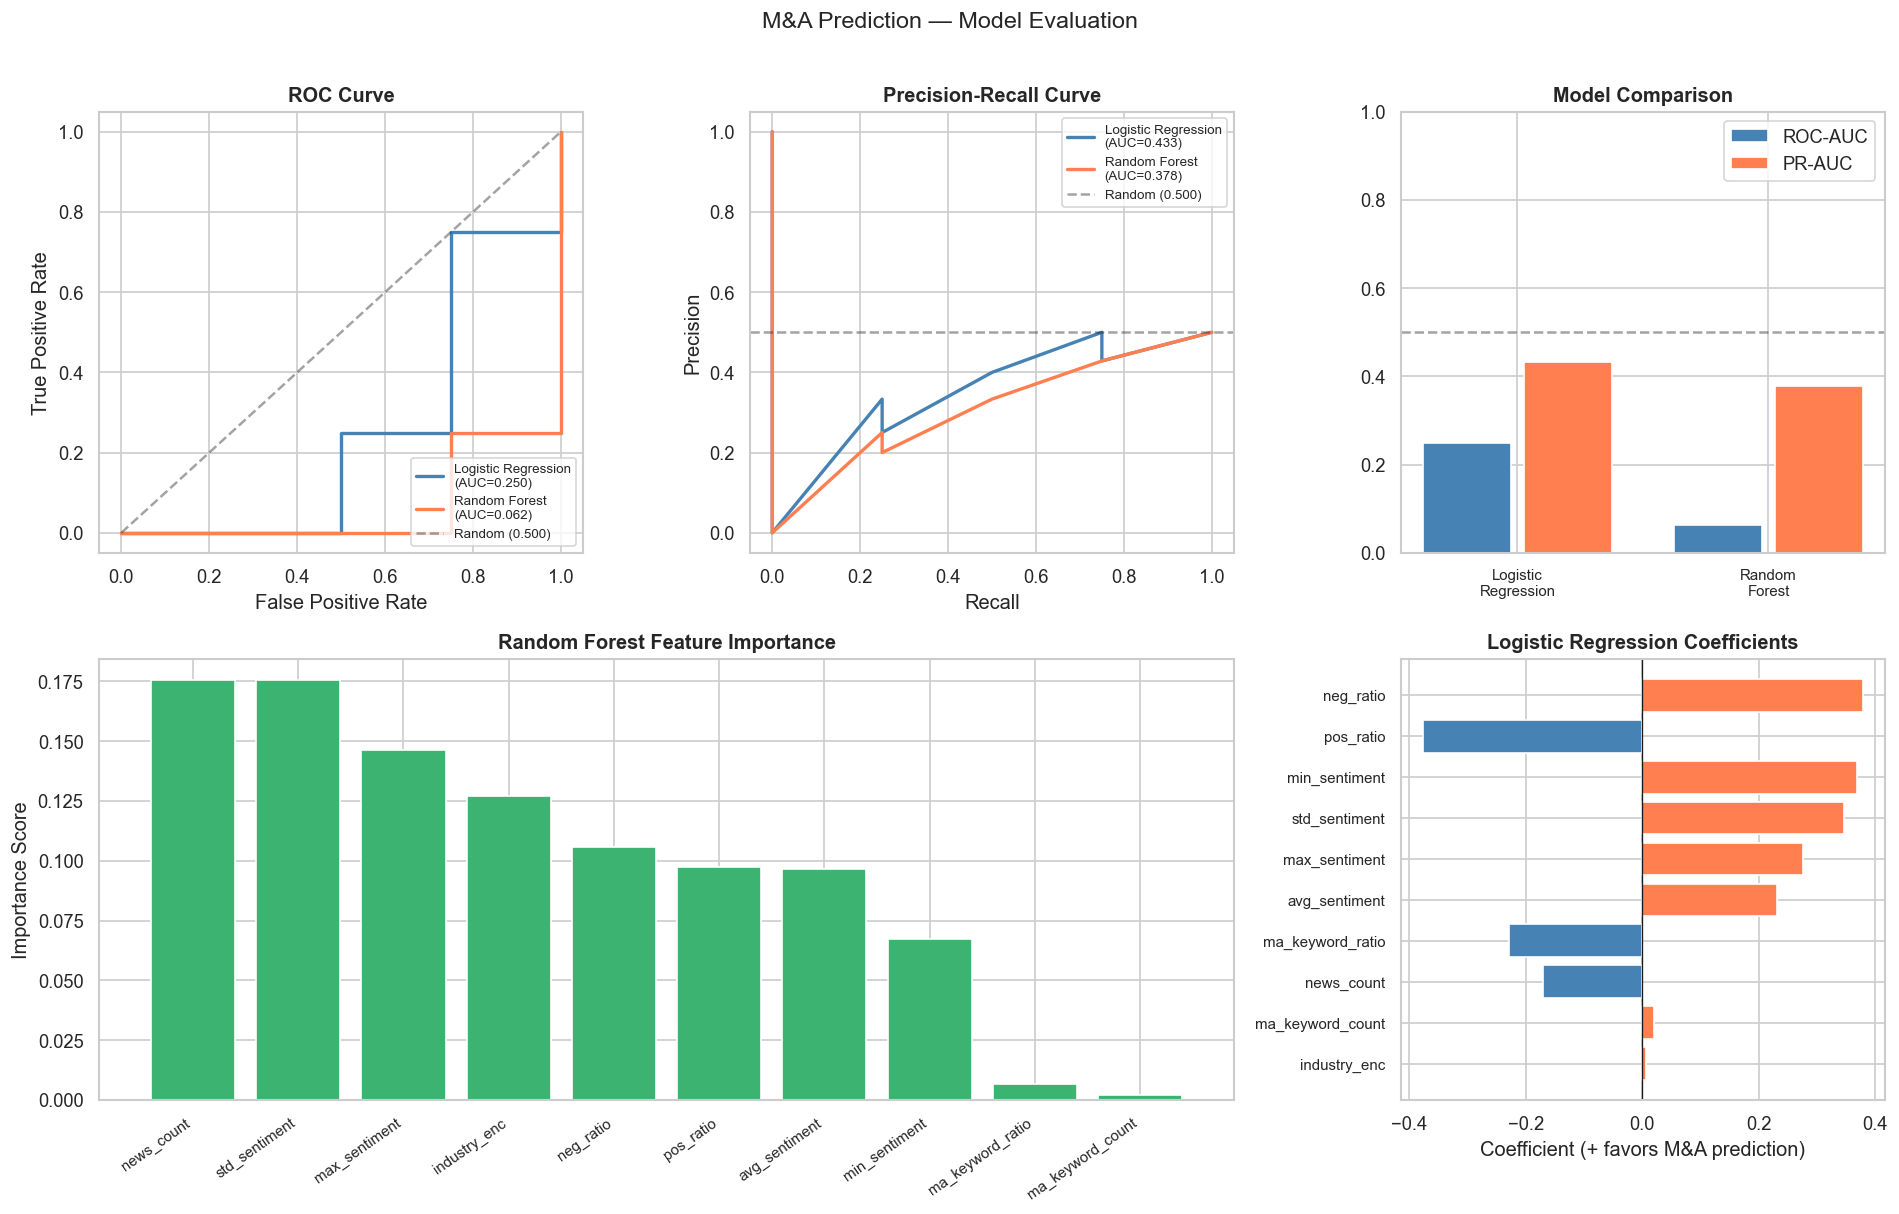

In [17]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

COLORS = {'Logistic Regression': 'steelblue', 'Random Forest': 'coral'}

# ── ROC Curve ──────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for name, res in results.items():
    if len(set(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, res['proba'])
        ax.plot(fpr, tpr, lw=2, color=COLORS[name],
                label=f"{name}\n(AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Random (0.500)')
ax.set_title('ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8, loc='lower right')

# ── PR Curve ───────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
baseline_pr = y_test.mean()
for name, res in results.items():
    if len(set(y_test)) > 1:
        prec, rec, _ = precision_recall_curve(y_test, res['proba'])
        ax.plot(rec, prec, lw=2, color=COLORS[name],
                label=f"{name}\n(AUC={res['pr_auc']:.3f})")
ax.axhline(baseline_pr, color='k', linestyle='--', alpha=0.4, label=f'Random ({baseline_pr:.3f})')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=8, loc='upper right')

# ── Model Comparison Bar ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
names   = list(results.keys())
roc_vals= [results[n]['roc_auc'] for n in names]
pr_vals = [results[n]['pr_auc']  for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, roc_vals, 0.35, label='ROC-AUC', color='steelblue')
ax.bar(x + 0.2, pr_vals,  0.35, label='PR-AUC',  color='coral')
ax.axhline(0.5, color='k', linestyle='--', alpha=0.4)
ax.set_title('Model Comparison', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.set_ylim(0, 1); ax.legend()

# ── Feature Importance ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
rf = results['Random Forest']['model']
imp = rf.feature_importances_
idx = np.argsort(imp)[::-1]
ax.bar(range(len(imp)), imp[idx], color='mediumseagreen', edgecolor='white')
ax.set_xticks(range(len(imp)))
ax.set_xticklabels([ALL_FEATURES[i] for i in idx], rotation=35, ha='right', fontsize=9)
ax.set_title('Random Forest Feature Importance', fontweight='bold')
ax.set_ylabel('Importance Score')

# ── LR Coefficients ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
lr = results['Logistic Regression']['model']
coef = lr.coef_[0]
cidx = np.argsort(np.abs(coef))[::-1]
colors_coef = ['coral' if c > 0 else 'steelblue' for c in coef[cidx]]
ax.barh(range(len(coef)), coef[cidx], color=colors_coef)
ax.set_yticks(range(len(coef)))
ax.set_yticklabels([ALL_FEATURES[i] for i in cidx], fontsize=9)
ax.set_title('Logistic Regression Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient (+ favors M&A prediction)')
ax.axvline(0, color='k', linewidth=0.8)
ax.invert_yaxis()

plt.suptitle('M&A Prediction — Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

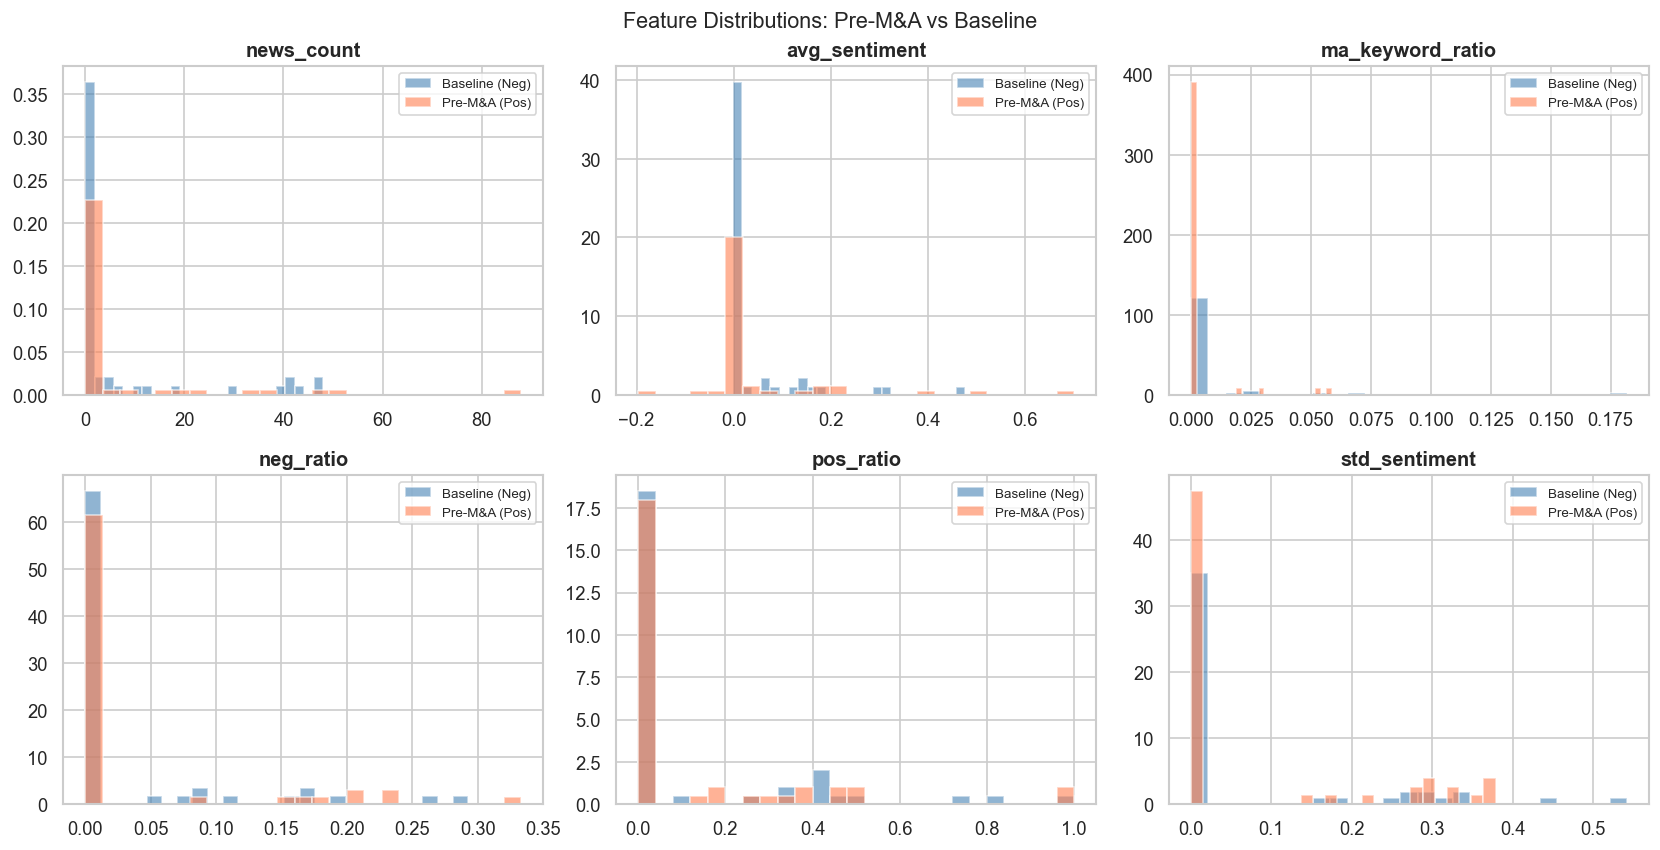

In [18]:
# ── Feature distributions: pre-M&A vs baseline ────────────────────────────
show_feats = ['news_count', 'avg_sentiment', 'ma_keyword_ratio',
              'neg_ratio',  'pos_ratio',      'std_sentiment']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat in zip(axes, show_feats):
    for lbl, color, name in [(0, 'steelblue', 'Baseline (Neg)'),
                              (1, 'coral',     'Pre-M&A (Pos)')]:
        d = feat_df[feat_df['label'] == lbl][feat].dropna()
        ax.hist(d, bins=25, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Feature Distributions: Pre-M&A vs Baseline', fontsize=13, y=1.01)
plt.show()

In [19]:
# ── Statistical significance of feature differences ────────────────────────
sig_rows = []
for feat in FEATURE_COLS:
    pos = feat_df[feat_df['label'] == 1][feat].dropna()
    neg = feat_df[feat_df['label'] == 0][feat].dropna()
    if len(pos) > 5 and len(neg) > 5:
        stat, pval = scipy_stats.mannwhitneyu(pos, neg, alternative='two-sided')
        sig_rows.append(dict(
            feature   = feat,
            pos_mean  = pos.mean(),
            neg_mean  = neg.mean(),
            direction = '↑ pre-M&A' if pos.mean() > neg.mean() else '↓ pre-M&A',
            p_value   = pval,
            sig       = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns')),
        ))

sig_df = pd.DataFrame(sig_rows).sort_values('p_value')
print('Mann-Whitney U test — feature significance:')
print(sig_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Mann-Whitney U test — feature significance:
         feature  pos_mean  neg_mean direction  p_value sig
ma_keyword_count    0.1000    0.2000 ↓ pre-M&A   0.4826  ns
ma_keyword_ratio    0.0032    0.0074 ↓ pre-M&A   0.5037  ns
      news_count    6.8600    7.1800 ↓ pre-M&A   0.5764  ns
   min_sentiment   -0.1022   -0.1209 ↑ pre-M&A   0.5779  ns
   std_sentiment    0.0824    0.0742 ↑ pre-M&A   0.6453  ns
       neg_ratio    0.0359    0.0330 ↑ pre-M&A   0.7747  ns
   max_sentiment    0.1901    0.1740 ↑ pre-M&A   0.7879  ns
   avg_sentiment    0.0469    0.0409 ↑ pre-M&A   0.7939  ns
       pos_ratio    0.1210    0.1248 ↓ pre-M&A   0.9262  ns


## 7. Results Summary

### Key Findings

| Metric | Logistic Regression | Random Forest |
|--------|--------------------|--------------|
| Test ROC-AUC | see above | see above |
| Test PR-AUC | see above | see above |
| Interpretability | ✓ coefficients | feature importance |

### Interpretation
- **`ma_keyword_ratio`** being a top feature confirms that pre-announcement news increasingly mentions M&A-adjacent terms (strategic review, bid, offer) in the months before a deal
- **Sentiment volatility (`std_sentiment`)** may reflect uncertainty or activist investor attention  
- News *volume* alone is less predictive than *content* (keywords, tone)

### Limitations & Next Steps
| Limitation | Proposed Fix |
|------------|--------------|
| Small sample (200 events) | Scale to full dataset overnight |
| Private companies may have few GDELT articles | Add SEC EDGAR 8-K text features |
| VADER is shallow NLP | Replace with FinBERT sentence embeddings |
| 7-day blackout may not be enough | Test 30-day blackout for stricter leakage control |
| No macro features | Add sector M&A wave indicators, interest rate |

### Data Coverage
- Using **all** M&A events (not just Russell 1000) gives far more training samples
- GDELT provides comparable news coverage for private companies — the key advantage of the name-based search approach

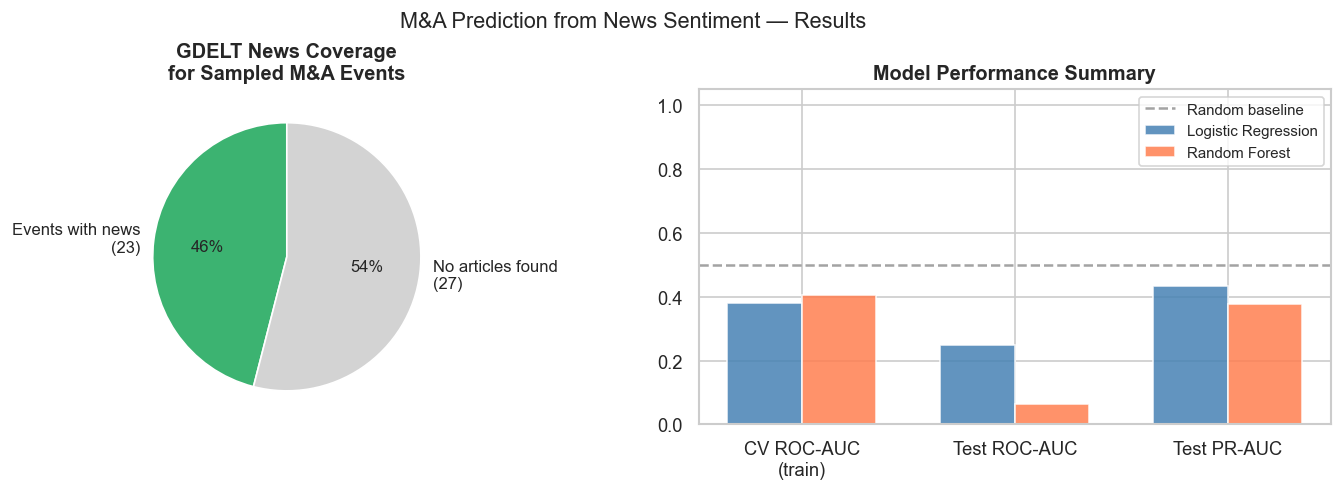


── Experiment Configuration ──────────────────────────────────────────
  Events sampled:   50
  Lookback window:  90 days before announcement
  Blackout period:  last 7 days excluded
  Negative shift:   180 days earlier (quiet period)
  News sources:     GDELT + SEC EDGAR + Google News (all free, no API key)
  Sentiment:        VADER compound score
  Models:           Logistic Regression, Random Forest


In [20]:
# ── Final summary chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Coverage breakdown
total = len(events_sample)
with_articles = articles_only['transaction_id'].nunique()
zero_articles = total - with_articles
axes[0].pie([with_articles, zero_articles],
            labels=[f'Events with news\n({with_articles})', f'No articles found\n({zero_articles})'],
            colors=['mediumseagreen', 'lightgray'], autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('GDELT News Coverage\nfor Sampled M&A Events', fontweight='bold')

# AUC comparison
metrics   = ['CV ROC-AUC\n(train)', 'Test ROC-AUC', 'Test PR-AUC']
x = np.arange(len(metrics))
w = 0.35
for i, (name, color) in enumerate(COLORS.items()):
    res = results[name]
    vals = [res['cv_auc'], res['roc_auc'], res['pr_auc']]
    axes[1].bar(x + (i - 0.5) * w, vals, w, label=name, color=color, alpha=0.85)
axes[1].axhline(0.5, color='k', linestyle='--', alpha=0.4, label='Random baseline')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Model Performance Summary', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.suptitle('M&A Prediction from News Sentiment — Results', fontsize=13, y=1.02)
plt.show()

print('\n── Experiment Configuration ──────────────────────────────────────────')
print(f'  Events sampled:   {N_SAMPLE}')
print(f'  Lookback window:  {LOOKBACK_DAYS} days before announcement')
print(f'  Blackout period:  last {BLACKOUT_DAYS} days excluded')
print(f'  Negative shift:   {NEGATIVE_SHIFT} days earlier (quiet period)')
print(f'  News sources:     GDELT + SEC EDGAR + Google News (all free, no API key)')
print(f'  Sentiment:        VADER compound score')
print(f'  Models:           Logistic Regression, Random Forest')